## Задание 1

На основании предоставленного датасета необходимо для каждого покупателя определить:

- 💳 **Предпочитаемый метод оплаты**  
  (например, наличные, карта, онлайн-платёж и т. д.);
- 💰 **Общие траты** — суммарная стоимость всех покупок клиента;
- 🧾 **Количество денег, потраченных на дополнительные услуги и аксессуары**.

In [2]:
import pandas as pd

In [5]:
data = pd.read_csv("files\\Electronic_sales_Sep2023-Sep2024.csv")
data.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        20000 non-null  int64  
 1   Age                20000 non-null  int64  
 2   Gender             19999 non-null  object 
 3   Loyalty Member     20000 non-null  object 
 4   Product Type       20000 non-null  object 
 5   SKU                20000 non-null  object 
 6   Rating             20000 non-null  int64  
 7   Order Status       20000 non-null  object 
 8   Payment Method     20000 non-null  object 
 9   Total Price        20000 non-null  float64
 10  Unit Price         20000 non-null  float64
 11  Quantity           20000 non-null  int64  
 12  Purchase Date      20000 non-null  object 
 13  Shipping Type      20000 non-null  object 
 14  Add-ons Purchased  15132 non-null  object 
 15  Add-on Total       20000 non-null  float64
dtypes: float64(3), int64(4

In [9]:
# --- 1. Предпочитаемый метод оплаты ---
preferred_payment = (
    data.groupby("Customer ID")["Payment Method"]
    .agg(lambda x: x.value_counts().idxmax())
)

# --- 2. Общие траты ---
total_spent = (
    data.groupby("Customer ID")["Total Price"]
    .sum()
)

# --- 3. Траты на дополнительные услуги и аксессуары ---
addon_spent = (
    data.groupby("Customer ID")["Add-on Total"]
    .sum()
)


# --- 4. Объединяем всё в один DataFrame ---
result = pd.concat([preferred_payment, total_spent, addon_spent], axis=1).reset_index()
result.columns = ["Customer ID", "Preferred Payment", "Total Spent", "Add-on Spent"]

# --- 5. Смотрим результат ---
print(result.head())

   Customer ID Preferred Payment  Total Spent  Add-on Spent
0         1000       Credit Card      6279.42         66.30
1         1002       Credit Card      5020.60         60.16
2         1003              Cash        41.50         35.56
3         1004       Credit Card        83.00         65.78
4         1005            Paypal     11779.11         75.33


## Задание 2

### 1. Получение данных

На основании предоставленного датасета необходимо рассчитать **доход**:

- 💸 по каждому **методу доставки** (*Shipping Type*);  
- 💰 по каждому **типу продукта** (*Product Type*);  
- 🧾 по **дополнительным услугам** (*Add-ons Purchased*):
  - за **каждый месяц**,
  - за **каждый квартал**.

---

### 2. Визуализация

Отобразите полученные данные на графиках, отражающих:

- распределение дохода по методам доставки;
- распределение дохода по типам продуктов;
- динамику дохода от дополнительных услуг по месяцам;
- динамику дохода от дополнительных услуг по кварталам.

---

In [15]:
# Доход по методу доставки
income_by_shipping = data.groupby("Shipping Type")['Total Price'].sum()

# Доход по типу продукта
income_by_product = data.groupby('Product Type')['Total Price'].sum()

# Преобразуем дату в тип datetime
data['Purchase Date'] = pd.to_datetime(data['Purchase Date'])

# Доход по дополнительным услугам по месяцам и кварталам
addons_by_month = data.groupby(data['Purchase Date'].dt.to_period('M'))['Add-on Total'].sum()
addons_by_quarter = data.groupby(data['Purchase Date'].dt.to_period('Q'))['Add-on Total'].sum()

In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

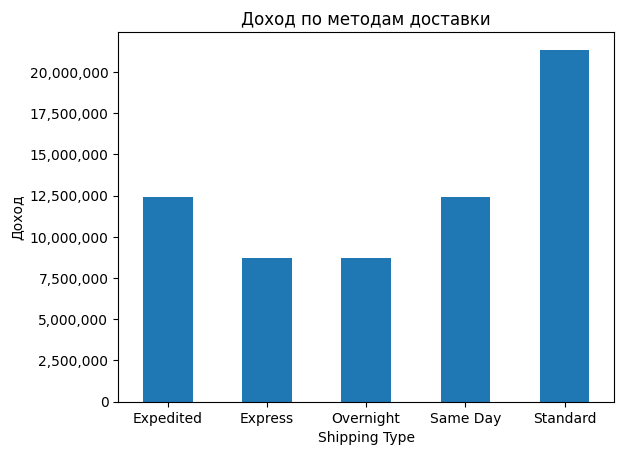

In [26]:
ax = income_by_shipping.plot(
    kind='bar',
    title='Доход по методам доставки',
    rot=0
)

ax.set_ylabel('Доход')
ax.set_xlabel('Shipping Type')

# Настройка формата чисел на оси Y
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.show()


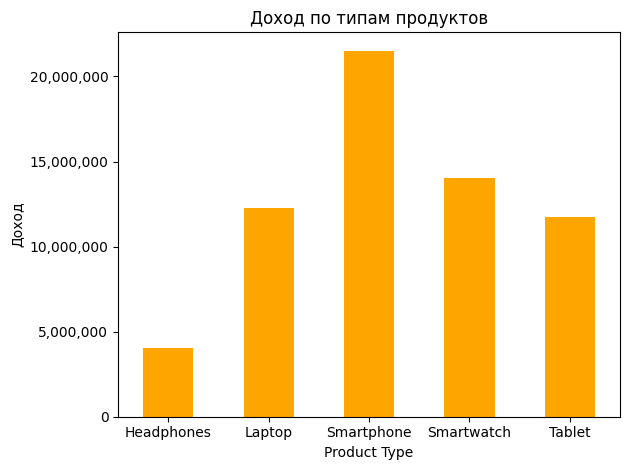

In [27]:
ax = income_by_product.plot(
    kind='bar',
    title='Доход по типам продуктов',
    rot=0,
    color='orange'
)

ax.set_ylabel('Доход')
ax.set_xlabel('Product Type')

# Настройка формата чисел на оси Y
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()


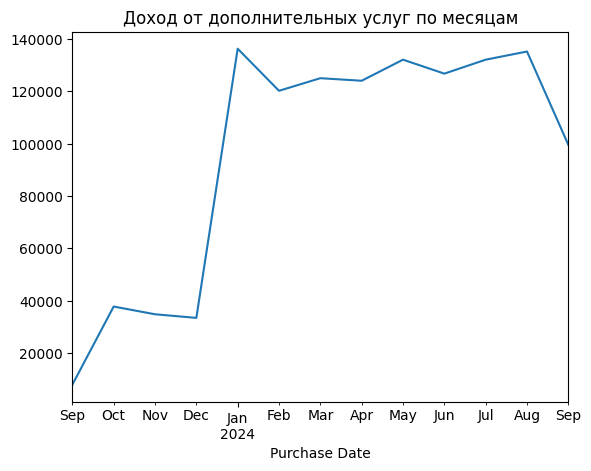

In [21]:
addons_by_month.plot(title='Доход от дополнительных услуг по месяцам')
plt.show()

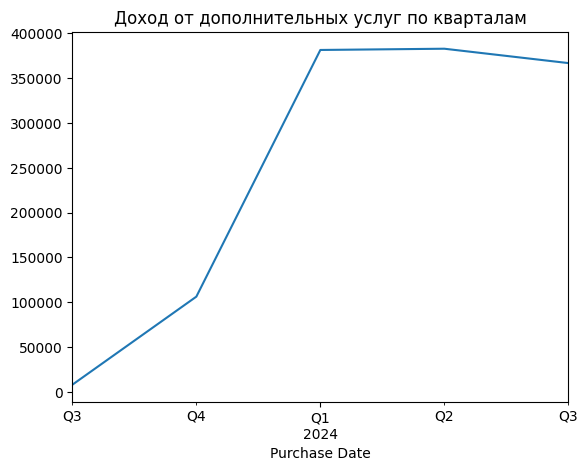

In [22]:
addons_by_quarter.plot(title='Доход от дополнительных услуг по кварталам')
plt.show()